# **Transformer para Tradução: Inglês → Francês**
---

Implementação do Transformer original (Encoder-Decoder) para tradução automática.

### **0. Introdução — Arquitetura Encoder-Decoder**

Diferente de modelos de linguagem (decoder-only como GPT), a tradução requer uma arquitetura **encoder-decoder**:

- **Encoder**: Processa a frase em inglês e cria representações contextuais
- **Decoder**: Gera a tradução em francês, atendendo às representações do encoder

Esta é a arquitetura original do artigo [*Attention is All You Need*](https://arxiv.org/pdf/1706.03762).

### **1. Configuração do Ambiente**

In [ ]:
!pip install transformers datasets sacrebleu sentencepiece -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
# Importações essenciais
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import json
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass
from tqdm import tqdm

# Datasets e tokenizers
from datasets import load_dataset
from transformers import AutoTokenizer

# Métricas de tradução
import sacrebleu

# Utilitários de treinamento
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.amp import autocast, GradScaler

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: Tesla T4


In [ ]:
# Seed para reprodutibilidade
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

### **2. Preparação do Dataset EN→FR**

In [ ]:
# Carregar o dataset WMT14 (Inglês-Francês)
print("Carregando o dataset WMT14 EN-FR...")
dataset = load_dataset('wmt14', 'fr-en', split='train[:100000]')  # 100k exemplos para começar
val_dataset = load_dataset('wmt14', 'fr-en', split='validation[:5000]')

print(f"Treino: {len(dataset):,} pares")
print(f"Validação: {len(val_dataset):,} pares")

# Exemplo
example = dataset[0]
print("\nExemplo:")
print(f"EN: {example['translation']['en']}")
print(f"FR: {example['translation']['fr']}")

Chargement du dataset WMT14 EN-FR...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

fr-en/train-00000-of-00030.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/40836715 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3003 [00:00<?, ? examples/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Train: 100,000 paires
Validation: 3,000 paires

Exemple:
EN: Resumption of the session
FR: Reprise de la session


### **3. Tokenizer Bilíngue MarianMT (EN↔FR)**

Isso garante um alinhamento semântico coerente entre as duas línguas.
Utilização de um **tokenizer SentencePiece compartilhado** pré-treinado para EN e FR.

In [ ]:
# Utilizar um tokenizer bilíngue pré-treinado MarianMT
tokenizer = AutoTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-fr")

vocab_size = len(tokenizer)
print(f"Vocab bilíngue (EN-FR): {vocab_size:,}")

# Tokens especiais Marian
PAD_IDX = tokenizer.pad_token_id
BOS_IDX = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else tokenizer.eos_token_id
EOS_IDX = tokenizer.eos_token_id
UNK_IDX = tokenizer.unk_token_id if tokenizer.unk_token_id is not None else 3

print(f"\nTokens especiais Marian:")
print(f"  PAD={PAD_IDX} ({tokenizer.pad_token})")
print(f"  BOS={BOS_IDX} ({tokenizer.convert_ids_to_tokens([BOS_IDX])[0]})")
print(f"  EOS={EOS_IDX} ({tokenizer.eos_token})")
print(f"  UNK={UNK_IDX}")

print(f"\n✓ Tokenizer bilíngue carregado com sucesso!")
print(f"  Encoder E decoder compartilham o mesmo vocabulário")

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/778k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Vocab bilingue (EN-FR): 59,514

Tokens spéciaux Marian:
  PAD=59513 (<pad>)
  BOS=0 (</s>)
  EOS=0 (</s>)
  UNK=1

✓ Tokenizer bilingue chargé avec succès!
  Encodeur ET décodeur partagent le même vocabulaire


/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


### **4. Codificação Posicional (Idêntica)**

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        return x + self.pe[:, :T, :]

### **5. Atenção de Produto Escalar Escalado**

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k: int, dropout: float = 0.1):
        super().__init__()
        self.scale = 1.0 / math.sqrt(d_k)
        self.drop = nn.Dropout(dropout)

    def forward(self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor,
                mask: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, torch.Tensor]:
        scores = torch.matmul(Q, K.transpose(-2, -1)) * self.scale

        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))

        attn = F.softmax(scores, dim=-1)
        attn = self.drop(attn)
        out = torch.matmul(attn, V)
        return out, attn

### **6. Atenção Multi-Cabeça**

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.q_proj = nn.Linear(d_model, d_model, bias=False)
        self.k_proj = nn.Linear(d_model, d_model, bias=False)
        self.v_proj = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)

        self.sdpa = ScaledDotProductAttention(self.d_k, dropout=dropout)
        self.proj_drop = nn.Dropout(dropout)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        return x.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

    def _merge_heads(self, x: torch.Tensor) -> torch.Tensor:
        B, H, T, D = x.shape
        return x.transpose(1, 2).contiguous().view(B, T, H * D)

    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor,
                mask: Optional[torch.Tensor] = None):
        Q = self._split_heads(self.q_proj(q))
        K = self._split_heads(self.k_proj(k))
        V = self._split_heads(self.v_proj(v))

        y, attn = self.sdpa(Q, K, V, mask=mask)
        y = self._merge_heads(y)
        y = self.out_proj(y)
        y = self.proj_drop(y)

        return y, attn

### **7. Rede Feed-Forward**

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model: int, d_ff: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

### **8. Bloco Encoder**

In [ ]:
class EncoderBlock(nn.Module):
    """Bloco Encoder: Self-Attention + FFN"""
    def __init__(self, d_model: int, n_heads: int = 8, d_ff: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x: torch.Tensor, mask: Optional[torch.Tensor] = None):
        # Self-attention
        h, attn = self.mha(self.ln1(x), self.ln1(x), self.ln1(x), mask=mask)
        x = x + h

        # FFN
        h = self.ffn(self.ln2(x))
        x = x + h

        return x, attn

### **9. Bloco Decoder**

In [ ]:
class DecoderBlock(nn.Module):
    """Bloco Decoder: Masked Self-Attention + Cross-Attention + FFN"""
    def __init__(self, d_model: int, n_heads: int = 8, d_ff: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.masked_mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.cross_mha = MultiHeadAttention(d_model, n_heads, dropout)
        self.ln3 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x: torch.Tensor, enc_output: torch.Tensor,
                tgt_mask: Optional[torch.Tensor] = None,
                src_mask: Optional[torch.Tensor] = None):
        # 1. Masked self-attention (só pode ver o passado)
        h, self_attn = self.masked_mha(self.ln1(x), self.ln1(x), self.ln1(x), mask=tgt_mask)
        x = x + h

        # 2. Cross-attention (atende ao encoder)
        h, cross_attn = self.cross_mha(self.ln2(x), enc_output, enc_output, mask=src_mask)
        x = x + h

        # 3. FFN
        h = self.ffn(self.ln3(x))
        x = x + h

        return x, self_attn, cross_attn

### **10. Modelo Transformer Completo (Encoder-Decoder)**

In [ ]:
@dataclass
class TransformerConfig:
    src_vocab_size: int  # Vocab inglês
    tgt_vocab_size: int  # Vocab francês
    d_model: int = 512
    n_heads: int = 8
    n_enc_layers: int = 6
    n_dec_layers: int = 6
    d_ff: int = 2048
    max_len: int = 512
    dropout: float = 0.1
    pad_idx: int = 0

In [ ]:
class Transformer(nn.Module):
    """Transformer Encoder-Decoder para tradução"""
    def __init__(self, config: TransformerConfig):
        super().__init__()
        self.config = config

        # Embeddings
        self.src_embedding = nn.Embedding(config.src_vocab_size, config.d_model, padding_idx=config.pad_idx)
        self.tgt_embedding = nn.Embedding(config.tgt_vocab_size, config.d_model, padding_idx=config.pad_idx)

        # Codificação posicional
        self.pos_encoding = PositionalEncoding(config.d_model, config.max_len)
        self.dropout = nn.Dropout(config.dropout)

        # Encoder
        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(config.d_model, config.n_heads, config.d_ff, config.dropout)
            for _ in range(config.n_enc_layers)
        ])

        # Decoder
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(config.d_model, config.n_heads, config.d_ff, config.dropout)
            for _ in range(config.n_dec_layers)
        ])

        # Projeção de saída
        self.ln_final = nn.LayerNorm(config.d_model)
        self.output_proj = nn.Linear(config.d_model, config.tgt_vocab_size, bias=False)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, 0.0, 0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, 0.0, 0.02)
        elif isinstance(module, nn.LayerNorm):
            nn.init.zeros_(module.bias)
            nn.init.ones_(module.weight)

    def create_masks(self, src: torch.Tensor, tgt: torch.Tensor):
        """Cria as máscaras para padding e causal"""
        # Máscara de padding da fonte [B, 1, 1, S]
        src_mask = (src != self.config.pad_idx).unsqueeze(1).unsqueeze(2)

        # Máscara causal + padding do alvo [B, 1, T, T]
        T = tgt.size(1)
        tgt_padding_mask = (tgt != self.config.pad_idx).unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]
        tgt_causal_mask = torch.tril(torch.ones((T, T), device=tgt.device, dtype=torch.bool)).unsqueeze(0).unsqueeze(0)
        tgt_mask = tgt_padding_mask & tgt_causal_mask

        return src_mask, tgt_mask

    def encode(self, src: torch.Tensor, src_mask: Optional[torch.Tensor] = None):
        """Codifica a fonte (inglês)"""
        x = self.src_embedding(src) * math.sqrt(self.config.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for block in self.encoder_blocks:
            x, _ = block(x, mask=src_mask)

        return x

    def decode(self, tgt: torch.Tensor, enc_output: torch.Tensor,
               tgt_mask: Optional[torch.Tensor] = None,
               src_mask: Optional[torch.Tensor] = None):
        """Decodifica para gerar o alvo (francês)"""
        x = self.tgt_embedding(tgt) * math.sqrt(self.config.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        for block in self.decoder_blocks:
            x, _, _ = block(x, enc_output, tgt_mask=tgt_mask, src_mask=src_mask)

        x = self.ln_final(x)
        logits = self.output_proj(x)

        return logits

    def forward(self, src: torch.Tensor, tgt: torch.Tensor):
        """Forward pass completo"""
        src_mask, tgt_mask = self.create_masks(src, tgt)

        # Codifica a fonte
        enc_output = self.encode(src, src_mask)

        # Decodifica o alvo
        logits = self.decode(tgt, enc_output, tgt_mask, src_mask)

        return logits

    @torch.no_grad()
    def translate(self, src: torch.Tensor, max_len: int = 100, beam_size: int = 5, length_penalty: float = 0.6):
        """Gera uma tradução com beam search"""
        self.eval()
        B = src.size(0)
        assert B == 1, "Beam search implementado apenas para batch_size=1"

        device = src.device

        # Codifica a fonte
        src_mask = (src != self.config.pad_idx).unsqueeze(1).unsqueeze(2)
        enc_output = self.encode(src, src_mask)  # [1, S, d_model]

        # Replica a codificação para cada beam
        enc_output = enc_output.repeat(beam_size, 1, 1)  # [beam_size, S, d_model]
        src_mask = src_mask.repeat(beam_size, 1, 1, 1)  # [beam_size, 1, 1, S]

        # Inicializa os beams com BOS
        beams = torch.full((beam_size, 1), BOS_IDX, dtype=torch.long, device=device)
        beam_scores = torch.zeros(beam_size, device=device)
        beam_scores[1:] = float('-inf')  # Apenas o primeiro beam está ativo inicialmente

        finished_beams = []

        for step in range(max_len):
            # Decodifica todos os beams
            src_dummy = src.repeat(beam_size, 1)  # Para create_masks
            _, tgt_mask = self.create_masks(src_dummy, beams)
            logits = self.decode(beams, enc_output, tgt_mask, src_mask)  # [beam_size, T, vocab]

            # Log-probabilidades do último token
            log_probs = F.log_softmax(logits[:, -1, :], dim=-1)  # [beam_size, vocab]

            # Pontuações combinadas
            vocab_size = log_probs.size(-1)
            scores = beam_scores.unsqueeze(1) + log_probs  # [beam_size, vocab]

            # Aplica penalidade de comprimento
            lp = ((5.0 + step + 1) / 6.0) ** length_penalty
            scores = scores / lp

            # Encontra os top-k melhores candidatos
            scores_flat = scores.view(-1)  # [beam_size * vocab]
            top_scores, top_indices = torch.topk(scores_flat, beam_size)

            # Converte índices planos em (beam_id, token_id)
            beam_ids = top_indices // vocab_size
            token_ids = top_indices % vocab_size

            # Constrói os novos beams
            new_beams = []
            new_scores = []

            for i in range(beam_size):
                beam_id = beam_ids[i]
                token_id = token_ids[i]
                score = top_scores[i]

                # Adiciona o token ao beam
                new_beam = torch.cat([beams[beam_id], token_id.unsqueeze(0)], dim=0)

                # Se EOS, adiciona aos beams terminados
                if token_id.item() == EOS_IDX:
                    finished_beams.append((new_beam, score.item()))
                else:
                    new_beams.append(new_beam)
                    new_scores.append(score)

            # Para se todos os beams terminaram
            if not new_beams:
                break

            # Padding dos novos beams
            max_beam_len = max(b.size(0) for b in new_beams)
            beams = torch.full((len(new_beams), max_beam_len), self.config.pad_idx, dtype=torch.long, device=device)
            for i, b in enumerate(new_beams):
                beams[i, :b.size(0)] = b

            beam_scores = torch.tensor(new_scores, device=device)

            # Completa com beams vazios se necessário
            if len(new_beams) < beam_size:
                padding_needed = beam_size - len(new_beams)
                beams = torch.cat([beams, torch.full((padding_needed, max_beam_len), self.config.pad_idx, dtype=torch.long, device=device)], dim=0)
                beam_scores = torch.cat([beam_scores, torch.full((padding_needed,), float('-inf'), device=device)], dim=0)

        # Seleciona o melhor beam terminado
        if finished_beams:
            best_beam = max(finished_beams, key=lambda x: x[1])[0]
        else:
            # Se nenhum beam terminou, pega o primeiro
            best_beam = beams[0]

        return best_beam.unsqueeze(0)  # [1, T]

### **11. Preparação dos Dados para o Treinamento**

Treinamento em **100k exemplos completos** (sem subamostragem).
**Importante**: Uso do mesmo tokenizer bilíngue para fonte E alvo.

In [ ]:
def tokenize_pair(example, max_len=128):
    """Tokeniza um par EN-FR com o tokenizer bilíngue compartilhado"""
    en_text = example['translation']['en']
    fr_text = example['translation']['fr']

    # Usa o MESMO tokenizer para EN e FR
    # Fonte (inglês) - sem tokens especiais
    en_tokens = tokenizer.encode(en_text, truncation=True, max_length=max_len, add_special_tokens=False)

    # Alvo (francês) - reserva 2 tokens para BOS/EOS
    fr_tokens = tokenizer.encode(fr_text, truncation=True, max_length=max_len-2, add_special_tokens=False)

    # Adiciona BOS/EOS apenas para o alvo
    fr_tokens = [BOS_IDX] + fr_tokens + [EOS_IDX]

    return {
        'src': en_tokens,
        'tgt': fr_tokens
    }

# Tokeniza dataset - TODOS os exemplos carregados (100k para treino)
print("Tokenização do dataset completo...")
print(f"⚠️  Isso pode levar alguns minutos para 100k exemplos")

tokenized_data = []
for i in tqdm(range(len(dataset)), desc="Tokenize treino"):
    tokenized_data.append(tokenize_pair(dataset[i]))

tokenized_val = []
for i in tqdm(range(len(val_dataset)), desc="Tokenize validação"):
    tokenized_val.append(tokenize_pair(val_dataset[i]))

print(f"  Treino: {len(tokenized_data):,} pares")
print(f"  Validação: {len(tokenized_val):,} pares")
print(f"\n✓ Tokenização concluída!")

Tokenisation du dataset complet...
⚠️  Cela peut prendre quelques minutes pour 100k exemples


Tokenize val: 100%|██████████| 3000/3000 [00:01<00:00, 2013.41it/s]

  Train: 100,000 paires
  Val: 3,000 paires

✓ Tokenization terminée!


In [ ]:
def collate_fn(batch, pad_idx=PAD_IDX):
    """Padding dinâmico para batch"""
    src_batch = [item['src'] for item in batch]
    tgt_batch = [item['tgt'] for item in batch]

    # Pad
    max_src_len = max(len(s) for s in src_batch)
    max_tgt_len = max(len(t) for t in tgt_batch)

    src_padded = torch.full((len(batch), max_src_len), pad_idx, dtype=torch.long)
    tgt_padded = torch.full((len(batch), max_tgt_len), pad_idx, dtype=torch.long)

    for i, (src, tgt) in enumerate(zip(src_batch, tgt_batch)):
        src_padded[i, :len(src)] = torch.tensor(src)
        tgt_padded[i, :len(tgt)] = torch.tensor(tgt)

    return src_padded, tgt_padded

# DataLoader
from torch.utils.data import DataLoader, Dataset

class TranslationDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_loader = DataLoader(
    TranslationDataset(tokenized_data),
    batch_size=32,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    TranslationDataset(tokenized_val),
    batch_size=32,
    shuffle=False,
    collate_fn=collate_fn
)

### **12. Inicialização do Modelo**

**Tokenizer bilíngue compartilhado** → mesmo vocab_size para encoder E decoder.

In [ ]:
# Configuração com tokenizer bilíngue
config = TransformerConfig(
    src_vocab_size=vocab_size,  # Mesmo vocabulário para EN e FR
    tgt_vocab_size=vocab_size,  # Tokenizer compartilhado
    d_model=256,        # Reduzido para RAM limitada
    n_heads=8,
    n_enc_layers=4,     # Reduzido de 6 para 4
    n_dec_layers=4,
    d_ff=1024,          # Reduzido de 2048
    max_len=128,
    dropout=0.1,
    pad_idx=PAD_IDX
)

model = Transformer(config).to(device)
print(f"Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")

Paramètres totaux: 53,067,776


### **13. Treinamento**

In [ ]:
# Criar diretório de salvamento
from pathlib import Path
import os

# Opção 1: Local
save_dir = Path('./translation_checkpoints')
save_dir.mkdir(exist_ok=True)

# Opção 2: Google Drive (descomentar se estiver no Colab)
# from google.colab import drive
# drive.mount('/content/drive')
# save_dir = Path('/content/drive/MyDrive/translation_checkpoints')
# save_dir.mkdir(parents=True, exist_ok=True)

print(f"Diretório de salvamento: {save_dir}")

Répertoire de sauvegarde: translation_checkpoints


In [ ]:
# Hiperparâmetros
learning_rate = 1e-4
num_epochs = 2  # 20-30 epochs com early stopping
grad_clip = 1.0
patience = 5  # Early stopping se não houver melhoria por 5 epochs

# Otimizador e agendador
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=len(train_loader), T_mult=2)

# Loss (ignora padding)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# Precisão mista
scaler = GradScaler()

print("Pronto para o treinamento!")
print(f"  Exemplos de treinamento: {len(tokenized_data):,}")
print(f"  Epochs máximo: {num_epochs}")
print(f"  Paciência do early stopping: {patience}")

Prêt pour l'entraînement!
  Exemples d'entraînement: 100,000
  Epochs max: 2
  Early stopping patience: 5


In [ ]:
# Loop de treinamento com early stopping
train_losses = []
val_losses = []
best_val_loss = float('inf')
epochs_without_improvement = 0

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)

        # Separa input/target para decoder
        tgt_input = tgt[:, :-1]   # Tudo exceto o último
        tgt_output = tgt[:, 1:]   # Tudo exceto o primeiro

        # Forward
        with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Libera memória
        del src, tgt, logits, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    # Salva melhor modelo e early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'config': config.__dict__
        }, save_dir / 'best_model.pt')
        print(f"✓ Novo melhor modelo salvo! Val Loss: {avg_val_loss:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"  Sem melhoria ({epochs_without_improvement}/{patience})")
        print(f"  Melhor Val Loss: {best_val_loss:.4f}")

        if epochs_without_improvement >= patience:
            print(f"\n⚠️  Early stopping após {epoch+1} epochs")
            break

Epoch 1/2: 100%|██████████| 3125/3125 [07:47<00:00,  6.69it/s, loss=3.0549]


Epoch 1: Train Loss = 3.1848, Val Loss = 4.1420
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 4.1420


Epoch 2/2: 100%|██████████| 3125/3125 [07:49<00:00,  6.66it/s, loss=2.6303]


Epoch 2: Train Loss = 2.7545, Val Loss = 3.7439
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.7439


### **13.5. Treinamento Adicional (Opcional)**

Use esta célula para continuar o treinamento se você quiser fazer mais epochs.

In [ ]:
# TREINAMENTO ADICIONAL
# Carrega o melhor modelo e continua o treinamento

# Número de epochs adicionais
additional_epochs = 5

# Carrega o melhor modelo salvo
checkpoint = torch.load(save_dir / 'best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
print(f"✓ Modelo carregado da epoch {checkpoint['epoch']+1}")
print(f"  Melhor Val Loss anterior: {checkpoint['val_loss']:.4f}")

# Loop de treinamento adicional
start_epoch = len(train_losses)  # Continua da última epoch

for epoch in range(additional_epochs):
    model.train()
    epoch_loss = 0

    current_epoch = start_epoch + epoch + 1
    pbar = tqdm(train_loader, desc=f"Epoch {current_epoch}/{start_epoch + additional_epochs}")

    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)

        # Separa input/target para decoder
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # Forward
        with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Libera memória
        del src, tgt, logits, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {current_epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    # Salva melhor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': current_epoch - 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'config': config.__dict__
        }, save_dir / 'best_model.pt')
        print(f"✓ Novo melhor modelo salvo! Val Loss: {avg_val_loss:.4f}")

print(f"\n✓ Treinamento adicional concluído!")
print(f"  Total de epochs: {len(train_losses)}")
print(f"  Melhor Val Loss: {best_val_loss:.4f}")

✓ Modèle chargé depuis l'epoch 2
  Best Val Loss précédent: 3.7439


Epoch 3/7: 100%|██████████| 3125/3125 [07:36<00:00,  6.84it/s, loss=2.5265]


Epoch 3: Train Loss = 2.4576, Val Loss = 3.6527
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.6527


Epoch 4/7: 100%|██████████| 3125/3125 [07:43<00:00,  6.75it/s, loss=2.0831]


Epoch 4: Train Loss = 2.3266, Val Loss = 3.4315
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.4315


...

Epoch 5: Train Loss = 2.1023, Val Loss = 3.2736
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.2736


Epoch 6/7: 100%|██████████| 3125/3125 [07:42<00:00,  6.76it/s, loss=1.9039]


Epoch 6: Train Loss = 1.9773, Val Loss = 3.2097
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.2097


Epoch 7/7: 100%|██████████| 3125/3125 [07:41<00:00,  6.77it/s, loss=1.9416]


Epoch 7: Train Loss = 1.9241, Val Loss = 3.1984
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.1984

✓ Entraînement supplémentaire terminé!
  Total epochs: 7
  Meilleur Val Loss: 3.1984


In [ ]:
# TREINAMENTO ADICIONAL
# Carrega o melhor modelo e continua o treinamento

# Número de epochs adicionais
additional_epochs = 5

# Carrega o melhor modelo salvo
checkpoint = torch.load(save_dir / 'best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
print(f"✓ Modelo carregado da epoch {checkpoint['epoch']+1}")
print(f"  Melhor Val Loss anterior: {checkpoint['val_loss']:.4f}")

# Loop de treinamento adicional
start_epoch = len(train_losses)  # Continua da última epoch

for epoch in range(additional_epochs):
    model.train()
    epoch_loss = 0

    current_epoch = start_epoch + epoch + 1
    pbar = tqdm(train_loader, desc=f"Epoch {current_epoch}/{start_epoch + additional_epochs}")

    for src, tgt in pbar:
        src, tgt = src.to(device), tgt.to(device)

        # Separa input/target para decoder
        tgt_input = tgt[:, :-1]
        tgt_output = tgt[:, 1:]

        # Forward
        with autocast(device_type='cuda', enabled=torch.cuda.is_available()):
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))

        # Backward
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Libera memória
        del src, tgt, logits, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validação
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for src, tgt in val_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {current_epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    # Salva melhor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': current_epoch - 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': avg_val_loss,
            'config': config.__dict__
        }, save_dir / 'best_model.pt')
        print(f"✓ Novo melhor modelo salvo! Val Loss: {avg_val_loss:.4f}")

print(f"\n✓ Treinamento adicional concluído!")
print(f"  Total de epochs: {len(train_losses)}")
print(f"  Melhor Val Loss: {best_val_loss:.4f}")

✓ Modèle chargé depuis l'epoch 7
  Best Val Loss précédent: 3.1984


Epoch 8/12: 100%|██████████| 3125/3125 [08:23<00:00,  6.21it/s, loss=1.8887]


Epoch 8: Train Loss = 1.9241, Val Loss = 3.1136
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.1136


Epoch 9/12: 100%|██████████| 3125/3125 [08:24<00:00,  6.19it/s, loss=1.6411]


Epoch 9: Train Loss = 1.7974, Val Loss = 3.0122
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 3.0122


...

Epoch 10: Train Loss = 1.6929, Val Loss = 2.9219
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 2.9219


Epoch 11/12: 100%|██████████| 3125/3125 [08:25<00:00,  6.18it/s, loss=1.4524]


Epoch 11: Train Loss = 1.6139, Val Loss = 2.8705
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 2.8705


Epoch 12/12: 100%|██████████| 3125/3125 [08:23<00:00,  6.20it/s, loss=1.3969]


Epoch 12: Train Loss = 1.5553, Val Loss = 2.8323
✓ Nouveau meilleur modèle sauvegardé! Val Loss: 2.8323

✓ Entraînement supplémentaire terminé!
  Total epochs: 12
  Meilleur Val Loss: 2.8323


### **14. Visualização dos Resultados**

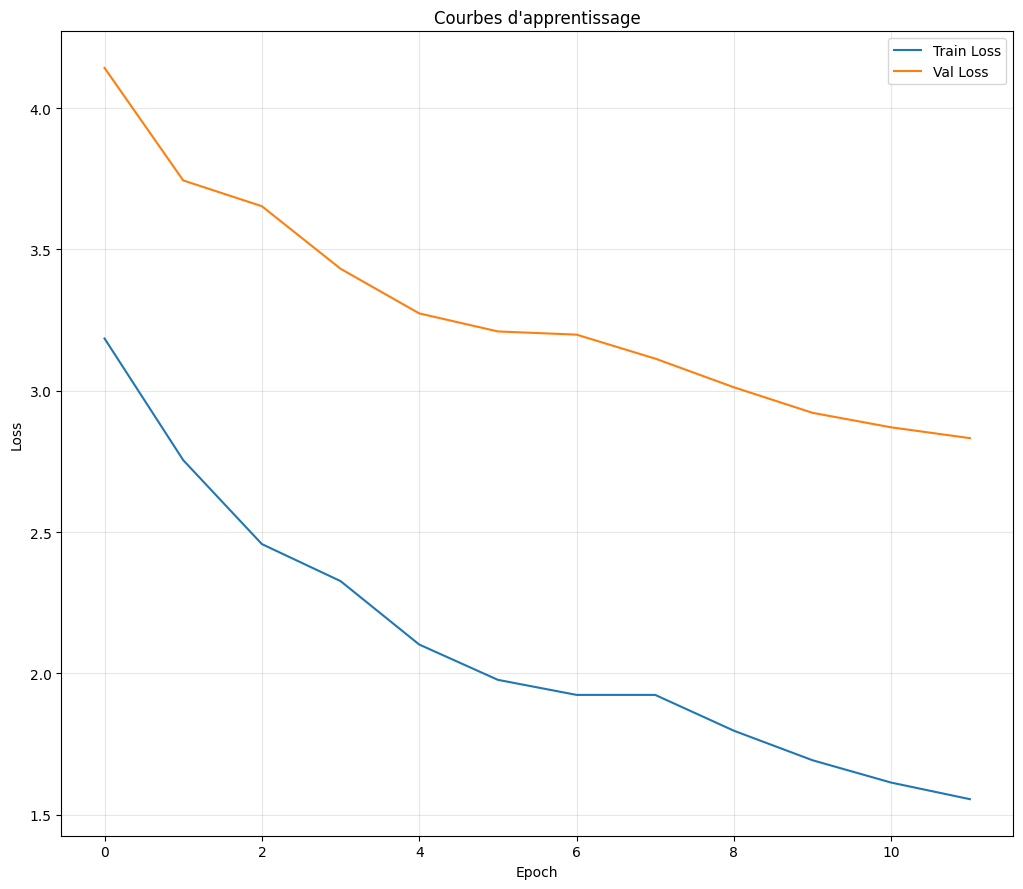

In [ ]:
# Curvas de aprendizado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Loss de Treino')
plt.plot(val_losses, label='Loss de Validação')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curvas de Aprendizado')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **15. Teste de Tradução**

In [ ]:
def test_translation(text_en: str, beam_size: int = 5):
    """Traduz um texto em inglês para francês com beam search"""
    model.eval()

    # Tokeniza a entrada com o tokenizer bilíngue
    src_tokens = tokenizer.encode(text_en, add_special_tokens=False)
    src = torch.tensor([src_tokens], dtype=torch.long).to(device)

    # Gera tradução com beam search
    with torch.no_grad():
        tgt = model.translate(src, max_len=100, beam_size=beam_size)

    # Decodifica com o tokenizer bilíngue
    tgt_tokens = tgt[0].cpu().tolist()
    translation = tokenizer.decode(tgt_tokens, skip_special_tokens=True)

    return translation

# Testes
test_sentences = [
    "Hello, how are you?",
    "The cat is on the table.",
    "I walk with my dog every day.",
    "The weather is sunny today"
    "What time is it?",
    "Good morning!"
]

print("="*60)
print("TESTES DE TRADUÇÃO EN→FR")
print("="*60)

for en_text in test_sentences:
    fr_text = test_translation(en_text)
    print(f"\nEN: {en_text}")
    print(f"FR: {fr_text}")
    print("-"*60)

TESTS DE TRADUCTION EN→FR

EN: Hello, how are you?
FR: Compte tenu de la manière ?
------------------------------------------------------------

EN: The cat is on the table.
FR: Les bombardements est la table.
------------------------------------------------------------

EN: I walk with my dog every day.
FR: Je viens à mon jour.
------------------------------------------------------------

EN: The weather is sunny todayWhat time is it?
FR: C'est-ce qu'il s'agissait d'aujourd'hui ?
------------------------------------------------------------

EN: Good morning!
FR: Le matin !
------------------------------------------------------------


### **16. Cálculo do BLEU Score**

In [ ]:
# Calcula BLEU no conjunto de validação
def calculate_bleu(model, val_dataset, n_samples=100):
    """Calcula o score BLEU no dataset de validação"""
    predictions = []
    references = []

    model.eval()

    for i in tqdm(range(min(n_samples, len(val_dataset)))):
        example = val_dataset[i]
        en_text = example['translation']['en']
        fr_ref = example['translation']['fr']

        # Traduz
        fr_pred = test_translation(en_text)

        predictions.append(fr_pred)
        references.append([fr_ref])  # Lista de referências

    # Calcula BLEU
    bleu = sacrebleu.corpus_bleu(predictions, references)

    return bleu.score, predictions, references

print("Calculando o BLEU score...")
bleu_score, preds, refs = calculate_bleu(model, val_dataset, n_samples=50)
print(f"\n✓ BLEU Score: {bleu_score:.2f}")

# Exibe alguns exemplos
print("\nExemplos de traduções:")
for i in range(min(5, len(preds))):
    print(f"\nReferência: {refs[i][0]}")
    print(f"Predição: {preds[i]}")

Calcul du BLEU score...


100%|██████████| 50/50 [00:41<00:00,  1.21it/s]


✓ BLEU Score: 10.25

Exemples de traductions:

Référence: Une stratégie républicaine pour contrer la réélection d'Obama
Prédiction: La stratégie visant à combattre le renouvellement électorateur de l'enquête.

Référence: Les dirigeants républicains justifièrent leur politique par la nécessité de lutter contre la fraude électorale.
Prédiction: Les principaux-clés justifiés leur politique de lutte contre la fraude électorale.

Référence: Or, le Centre Brennan considère cette dernière comme un mythe, affirmant que la fraude électorale est plus rare aux États-Unis que le nombre de personnes tuées par la foudre.
Prédiction: Néanmoins, l' Observatoire Buitenweg considère que la fraude électorale est très rare dans les États-Unis que le nombre de personnes tuées.

Référence: D'ailleurs, les avocats républicains n'ont recensé que 300 cas de fraude électorale aux États-Unis en dix ans.
Prédiction: En effet, les avocats identifiés ne sont que 300 millions de cas de fraude électorale dans les Ét

### **17. Salvamento Final**

In [ ]:
# Salva o modelo final
final_checkpoint = {
    'model_state_dict': model.state_dict(),
    'config': config.__dict__,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'best_val_loss': best_val_loss,
    'bleu_score': bleu_score,
    'tokenizer': 'Helsinki-NLP/opus-mt-en-fr',
    'shared_vocab': True
}

torch.save(final_checkpoint, save_dir / 'transformer_en_fr_final.pt')
print(f"✓ Modelo final salvo em {save_dir / 'transformer_en_fr_final.pt'}")

# Salva configuração em JSON
with open(save_dir / 'config.json', 'w') as f:
    json.dump({
        'config': config.__dict__,
        'metrics': {
            'best_val_loss': best_val_loss,
            'bleu_score': bleu_score,
            'total_epochs': len(train_losses)
        },
        'tokenizer': {
            'model': 'Helsinki-NLP/opus-mt-en-fr',
            'type': 'MarianMT',
            'shared_vocab': True,
            'vocab_size': vocab_size
        },
        'training': {
            'num_examples': len(tokenized_data),
            'beam_search': True,
            'beam_size': 5,
            'length_penalty': 0.6
        }
    }, f, indent=2)

print("✓ Configuração salva")

✓ Modèle final sauvegardé dans translation_checkpoints/transformer_en_fr_final.pt
✓ Configuration sauvegardée


In [ ]:
# Baixa os checkpoints para o seu computador
from google.colab import files
import shutil

# Compacta a pasta de checkpoints
shutil.make_archive('translation_checkpoints', 'zip', './translation_checkpoints')

# Baixa o arquivo ZIP
files.download('translation_checkpoints.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## **Resumo das Diferenças com o Modelo de Linguagem**

| Aspecto | Modelo de Linguagem (GPT) | Tradução (Transformer) |
|--------|------------------------|-------------------------|
| Arquitetura | Apenas Decoder | Encoder-Decoder |
| Entrada | Texto em uma língua | Pares de textos (EN-FR) |
| Tarefa | Geração de texto | Tradução |
| Atenção | Self-attention causal | Self + Cross-attention |
| Dataset | Corpus monolíngue | Corpus paralelo |
| Métrica | Perplexidade | BLEU score |
| Vocabulário | 1 vocabulário | 2 vocabulários (src/tgt) |